In [1]:
import findspark
import os
#findspark.init() 
SPARK_HOME='/opt/cloudera/parcels/CDH/lib/spark'
# SPARK_HOME='/home/qiany/.conda/envs/py37'
# os.environ['SPARK_HOME'] = '/home/qiany/.conda/envs/py37'
findspark.init(SPARK_HOME)

In [2]:
import time
import math
import copy
import csv
import json
import os
import codecs
import subprocess
#from hdfs import InsecureClient
import numpy as np
#from pyspark import SparkContext
from pyspark import SQLContext
from pyspark.sql import Row
from pyspark.sql import functions as F
from pyspark.sql.functions import create_map
from pyspark.sql.functions import array_union,flatten,array_sort,coalesce,broadcast,collect_list, collect_set, udf, array_remove, log, lit, first, col, array, sort_array,split, explode, desc, asc, row_number,isnan, when, count
from pyspark.sql.types import *
import rtree
from pyspark.sql import Window
#import igraph
#from igraph import Graph
import geofeather
from pyspark.storagelevel import StorageLevel

In [3]:
# /local/data/yuehui/pyspark/data/Part3_TopoSim/ALS_L1B_20190410_final/ALS_L1B_20190410T174554_181213_small_crop_as_100000.off
# /local/data/yuehui/pyspark/data/Part3_TopoSim/ALS_L1B_20190410_final/ALS_L1B_20190410T174554_181213_3_as_100000.off
# /local/data/yuehui/pyspark/data/Part3_TopoSim/ALS_L1B_20190410_final/ALS_L1B_20190410T174554_181213_small_crop_tiny_test_as_100000.off
# /local/data/yuehui/pyspark/data/Part3_TopoSim/ALS_L1B_20190410_final/ALS_L1B_20190410T174554_181213_3_crop_as_100000.off
# /local/data/yuehui/pyspark/data/Part3_TopoSim/ALS_L1B_20190410T183726_185444_1/ALS_L1B_20190410T183726_185444_1.off
# /local/data/yuehui/pyspark/data/Part3_TopoSim/ALS_L1B_20190410T153919_155000_1/ALS_L1B_20190410T153919_155000_1.off
# /local/data/yuehui/pyspark/data/Part3_TopoSim/ALS_L1B_20190410T174554_181213/ALS_L1B_20190410T174554_181213.off

t_whole_program_0 = time.time()

tin_file = input("Here is a programe to compute the Forman gradient, please input the absolute or relative path in local disk to your TIN file:")
# tin_file = '/local/data/yuehui/pyspark/data/Part3_TopoSim/ALS_L1B_20190410_final/ALS_L1B_20190410T174554_181213_small_crop_as_100000.off'

print("\n********************")

# get the directory to the TIN file
tin_directory = os.path.dirname(tin_file)
print("tin_directory: ", tin_directory)

# seaice
# seaice_11122025
# seaice_simplify_ele
# ALS_L1B_20190410T174554_181213_small_crop_tiny_test
# ALS_L1B_20190410T174554_181213_small_crop_tiny_test_pers_0.5
# ALS_L1B_20190410T174554_181213_3_crop_pers_0.25
# ALS_L1B_20190410T174554_181213_3_pers_025
# ALS_L1B_20190410T174554_181213_3_pers_050
# ALS_L1B_20190410T183726_185444_1_pers_025
# ALS_L1B_20190410T153919_155000_1_pers_025
# ALS_L1B_20190410T174554_181213_pers_025
directory = input("The HDFS directory where you want to store DataFrames:")

# simplify_with_order = input("Simplify with order('y' or 'n'):") or "n"
simplify_with_order = "n"

# porsist_thre = input("What is the persistence value threshold (m) you want to set:") or "0.25"

# get the basename to the TIN file
tin_basename = os.path.basename(tin_file) # input_vertices_2.off
print("tin_basename: ", tin_basename)

# get the filename of the TIN file
tin_filename = os.path.splitext(tin_basename)[0] # input_vertices_2
print("tin_filename: ", tin_filename)

# get the type of TIN file: off, tri, etc
tin_extension = os.path.splitext(tin_basename)[1] # .off
print("tin_extension: ", tin_extension)
print("\n********************")

Here is a programe to compute the Forman gradient, please input the absolute or relative path in local disk to your TIN file: /local/data/yuehui/pyspark/data/Part3_TopoSim/ALS_L1B_20190410T153919_155000_1/ALS_L1B_20190410T153919_155000_1.off



********************
tin_directory:  /local/data/yuehui/pyspark/data/Part3_TopoSim/ALS_L1B_20190410T153919_155000_1


The HDFS directory where you want to store DataFrames: ALS_L1B_20190410T153919_155000_1_pers_025


tin_basename:  ALS_L1B_20190410T153919_155000_1.off
tin_filename:  ALS_L1B_20190410T153919_155000_1
tin_extension:  .off

********************


In [4]:
# filtra is the order of each vertex, the order is obtained by ranking elevation values of vertices
filtra = input("Do you have filtration data?") or "yes"
# filtra = 'yes'

if filtra.lower() == 'no':    
    Basic_Data = input("Do you have basic pts and tri data?")
    
Num_executor = input("spark.executor.instances:") or "16"
Num_core_per_executor = input("spark.executor.cores:") or "5"
Memory_executor = input("spark.executor.memory? Please end with 'g':") or "56g"
MemoryOverhead_executor = input("spark.executor.memoryOverhead? Please end with 'g':") or "32g"

# Num_core_per_driver = Num_core_per_executor
# Memory_driver = Memory_executor
# MemoryOverhead_driver = MemoryOverhead_executor

Num_core_per_driver = '5'
Memory_driver = '56g'
MemoryOverhead_driver = '24g'

Num_shuffle_partitions = input("spark.sql.shuffle.partitions:") or "160"

Do you have filtration data? yes
spark.executor.instances: 16
spark.executor.cores: 5
spark.executor.memory? Please end with 'g': 
spark.executor.memoryOverhead? Please end with 'g': 
spark.sql.shuffle.partitions: 160


In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, expr, first
from pyspark import StorageLevel
import geopandas as gpd
import pandas as pd
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, LongType, FloatType, ArrayType, MapType
from shapely.geometry import Point
from shapely.geometry import Polygon

from sedona.register import SedonaRegistrator
from sedona.core.SpatialRDD import SpatialRDD, PointRDD, CircleRDD, PolygonRDD, LineStringRDD
from sedona.core.enums import FileDataSplitter
from sedona.utils.adapter import Adapter
from sedona.core.spatialOperator import KNNQuery
from sedona.core.spatialOperator import JoinQuery
from sedona.core.spatialOperator import JoinQueryRaw
from sedona.core.spatialOperator import RangeQuery
from sedona.core.spatialOperator import RangeQueryRaw
from sedona.core.formatMapper.shapefileParser import ShapefileReader
from sedona.core.formatMapper import WkbReader
from sedona.core.formatMapper import WktReader
from sedona.core.formatMapper import GeoJsonReader
from sedona.sql.types import GeometryType
from sedona.core.enums import GridType
from sedona.core.SpatialRDD import RectangleRDD
from sedona.core.enums import IndexType
from sedona.core.geom.envelope import Envelope
from sedona.utils import SedonaKryoRegistrator, KryoSerializer

In [6]:
os.environ['PYSPARK_PYTHON'] = "./environment/bin/python"
#os.environ['PYSPARK_PYTHON'] = "/home/qiany/.conda/envs/py37/bin/python"
os.environ['YARN_CONF_DIR'] = "/opt/cloudera/parcels/CDH/lib/spark/conf/yarn-conf"

In [7]:
'''
spark.executor.cores: # Number of concurrent tasks an executor can run, euqals to the number of cores to use on each executor
spark.executor.instances: # Number of executors for the spark application
spark.executor.memory: # Amount of memory to use for each executor that runs the task
spark.executor.memoryOverhead:
spark.driver.cores: # Number of cores to use for the driver process; the default number is 1
spark.driver.memory: # Amount of memory to use for the driver
spark.driver.maxResultSize: to define the maximum limit of the total size of the serialized result that a driver can store for each Spark collect action
spark.default.parallelism: # Default number of partitions in RDDs returned by transformations like join, reduceByKey, and parallelize when not set by user. It can be set as spark.executor.instances * spark.executor.cores * 2
spark.sql.shuffle.partitions: determine how many partitions are used when data is shuffled between nodes, e.g., joins or aggregations. usually 1~5 times of executor.instances * executor.cores
spark.memory.storageFraction: determines the fraction of the heap space that is allocated to caching RDDs and DataFrames in memory.
spark.kryoserializer.buffer.max: determine the maximum of data that can be serialized at once; this must be larger than any object we attempt to serialize
spark.rpc.message.maxSize: # Maximum message size (in MiB) to allow in "control plane" communication; generally only applies to map output size information sent between executors and the driver. To communicate between the nodes, Spark uses a protocol called RPC (Remote Procedure Call), which sends messages back and forth. The spark.rpc.message.maxSize parameter limits how big these messages can be. 
spark.sql.broadcastTimeout: Spark will wait for this amount of time before giving up on broadcasting a table. Broadcasting can take a long time if the table is large or if there is a shuffle operation before it.
spark.sql.autoBroadcastJoinThreshold: Spark will broadcast a table to all worker nodes when performing a join if its size is less than this value; -1 means disabling broadcasting
'''

date = time.strftime("%m,%d,%Y")
date_name = date.split(',')[0] + date.split(',')[1] + date.split(',')[2]

hour = time.strftime("%H,%M")
hour_name = hour.split(',')[0] + hour.split(',')[1]

# set the Spark app name
spark_app_name = "Step_0_roughness_second_order_" + tin_filename + '_' + date_name + '_' + hour_name
print("spark_app_name:", spark_app_name)

spark = SparkSession \
.builder \
.appName(spark_app_name) \
.master('yarn') \
.config("spark.serializer", KryoSerializer.getName) \
.config("spark.kryo.registrator", SedonaKryoRegistrator.getName) \
.config('spark.jars','sedona-core-2.4_2.11-1.0.0-incubating.jar,sedona-sql-2.4_2.11-1.0.0-incubating.jar,sedona-python-adapter-2.4_2.11-1.0.0-incubating.jar,sedona-viz-2.4_2.11-1.0.0-incubating.jar,geotools-wrapper-geotools-24.0.jar,graphframes-0.8.0-spark2.4-s_2.11.jar') \
.config('spark.executor.cores', Num_core_per_executor) \
.config('spark.executor.instances', Num_executor) \
.config('spark.executor.memory', Memory_executor) \
.config('spark.executor.memoryOverhead', MemoryOverhead_executor) \
.config('spark.driver.cores', Num_core_per_driver) \
.config('spark.driver.memory', Memory_driver) \
.config('spark.driver.memoryOverhead', MemoryOverhead_driver) \
.config('spark.driver.maxResultSize', '0') \
.config('spark.dynamicAllocation.enabled', 'false') \
.config('spark.network.timeout', '10000001s') \
.config('spark.executor.heartbeatInterval', '10000000s') \
.config('spark.sql.shuffle.partitions', Num_shuffle_partitions) \
.config("spark.default.parallelism", '200') \
.config("spark.kryoserializer.buffer.max", "1024mb") \
.config('spark.rpc.message.maxSize', '256') \
.config("spark.sql.broadcastTimeout", "36000") \
.config("spark.sql.autoBroadcastJoinThreshold", "-1") \
.config("spark.python.profile", "true") \
.config("spark.eventLog.enabled", "true") \
.config('spark.yarn.dist.archives', '/local/data/yuehui/py37.tar.gz#environment') \
.getOrCreate()

spark_app_name: Step_0_roughness_second_order_ALS_L1B_20190410T153919_155000_1_03222026_2257


In [8]:
import sys
sys.path.append("/local/data/yuehui/pyspark/Topo_Simplification/code")

#### read vertices file: a parquet or a CSV file

In [9]:
file_type = '0'

In [10]:
if file_type == 'parquet' or file_type == '0':
    file_df_ver_order = directory + '/' + tin_filename + '_filtra_pts' + '.parquet'
    df_ver_order = spark.read.parquet(file_df_ver_order)
    df_ver_order.printSchema()
    
    file_df_tri_order = directory + '/' + tin_filename + '_filtra_tri' + '.parquet'
    df_tri_order = spark.read.parquet(file_df_tri_order)
    df_tri_order.printSchema()
else:
    # read_ver_order() is a function used to read vertices from a csv file
    def read_ver_order(filtra, directory, tin_filename):
        '''
        this function has three input parameters.
        filtra: 'yes' or 'no', yes means that the input csv file is ordered by default
        directory: a string denoting the directory to a TIN file
        tin_filename: a string denoting the file name of a TIN without extension, e.g., Canyon_Lake_Gorge_TX
        '''
        if filtra.lower() == 'yes': # 'yes' means we have already computed the filtra value for each vertex
            schema_ver_origin = StructType([ \
                StructField("x",FloatType(),True), \
                StructField("y",FloatType(),True), \
                StructField("ele",FloatType(),True), \
                StructField("self_index",IntegerType(),True), \
                StructField("self_order",IntegerType(),True) \
              ])
            
            hdfs_tin_pts_origin = directory + "/" + tin_filename + '_filtra_pts.csv'
        
            df_ver_order = spark.read.format("csv") \
                  .option("header", False) \
                  .schema(schema_ver_origin)\
                  .load(hdfs_tin_pts_origin)
            print("Number of partitions for df_ver_order:", df_ver_order.rdd.getNumPartitions())
            
        if filtra.lower() == 'no': # 'no' means we need to rank vertices to get their filtra values
            schema_ver_origin = StructType([ \
                StructField("x",FloatType(),True), \
                StructField("y",FloatType(),True), \
                StructField("ele",FloatType(),True), \
                StructField("self_index",IntegerType(),True) \
              ])
            
            hdfs_tin_pts_origin = directory + "/" + tin_filename + '_pts_origin.csv'
        
            df_ver_origin = spark.read.format("csv") \
                  .option("header", False) \
                  .schema(schema_ver_origin)\
                  .load(hdfs_tin_pts_origin)
            
            print("Number of partitions for df_ver_origin:", df_ver_origin.rdd.getNumPartitions())
            
            # define a window for the ordering
            # row_number() function along with partitionBy() of other column populates the row number by group
            # Since we want to order the whole DataFrame, so we don't need the partitionBy() function
            w = Window().orderBy(col('ele').asc())
            df_ver_order = df_ver_origin.withColumn("self_order", F.row_number().over(w) -1) # let the row number start from 0
            print("Number of partitions for df_ver_order:", df_ver_order.rdd.getNumPartitions())
            
        return df_ver_order
    
    # read vertices
    df_ver_order = read_ver_order(filtra, directory, tin_filename)
    df_ver_order.printSchema()
    
    # read_tetra_order() is a function used to read tetrahedron from a csv file
    def read_tri_order(hdfs_tin_tri_origin):
        '''
        hdfs_tin_tri_origin: path to the input triangle csv file
        '''
            
        schema_tri_origin = StructType([ \
            StructField("tri_order",IntegerType(),True), \
            StructField("r1",IntegerType(),True), \
            StructField("r2",IntegerType(),True), \
            StructField("r3",IntegerType(),True), \
            StructField("r1_ele",FloatType(),True), \
            StructField("r2_ele",FloatType(),True), \
            StructField("r3_ele",FloatType(),True)
          ])
    
        df_tri_origin = spark.read.format("csv") \
              .option("header", False) \
              .schema(schema_tri_origin)\
              .load(hdfs_tin_tri_origin)
            
        return df_tri_origin
    
    
    # read tetrahedra
    hdfs_tin_tri_origin = directory + "/" + tin_filename + '_filtra_tri.csv'
    
    df_tri_order = read_tri_order(hdfs_tin_tri_origin)
    df_tri_order.printSchema()

root
 |-- x: float (nullable = true)
 |-- y: float (nullable = true)
 |-- ele: float (nullable = true)
 |-- self_index: integer (nullable = true)
 |-- self_order: integer (nullable = true)

root
 |-- tri_order: integer (nullable = true)
 |-- r1: integer (nullable = true)
 |-- r2: integer (nullable = true)
 |-- r3: integer (nullable = true)
 |-- r1_ele: float (nullable = true)
 |-- r2_ele: float (nullable = true)
 |-- r3_ele: float (nullable = true)



### average roughness

In [11]:
df_ver_order.agg(F.stddev("ele").alias("stddev_ele")).show()

+-------------------+
|         stddev_ele|
+-------------------+
|0.33500786513577424|
+-------------------+



In [12]:
# sort the extreme vertices of a triangle in ascending order, e.g., (2,5,3) -> (2,3,5)

'''
def get_tri_array(r1, r2, r3):
# get_multi_pt_index is used to obtain the adjacent vertexes index, including the vertex itself
# pt_list1: partial adjacent vertex indexes of join result 1
# pt_list2: partial adjacent vertex indexes of join result 2
    tri = [r1, r2, r3]    
    tri.sort(reverse=True)
    
    return tri

# convert a function to an udf and determine the return type
# https://spark.apache.org/docs/3.1.3/api/python/reference/api/pyspark.sql.functions.udf.html
get_tri_array_udf = udf(get_tri_array, ArrayType(IntegerType()))
df_tri_order = df_tri_order.withColumn("tri", get_tri_array_udf(df_tri_order.r1, df_tri_order.r2, df_tri_order.r3))
'''

df_tri_order = df_tri_order.withColumn("tri_origin", F.array("r1", "r2", "r3")).withColumn("tri_ele_origin", F.array("r1_ele", "r2_ele", "r3_ele"))
df_tri_order = df_tri_order.withColumn("tri", sort_array("tri_origin", False)).drop("tri_origin") # sort_array("tri", False), False means descending order
df_tri_order = df_tri_order.withColumn("tri_ele", sort_array("tri_ele_origin", False)).drop("tri_ele_origin") # sort_array("tri", False), False means descending order

df_tri_order.printSchema()
df_tri_order.rdd.getNumPartitions()
#df_tri_order.show()

root
 |-- tri_order: integer (nullable = true)
 |-- r1: integer (nullable = true)
 |-- r2: integer (nullable = true)
 |-- r3: integer (nullable = true)
 |-- r1_ele: float (nullable = true)
 |-- r2_ele: float (nullable = true)
 |-- r3_ele: float (nullable = true)
 |-- tri: array (nullable = false)
 |    |-- element: integer (containsNull = true)
 |-- tri_ele: array (nullable = false)
 |    |-- element: float (containsNull = true)



195

#### globally get VT relation

In [13]:
# function to get VT directly from DF_T
def get_VT(df_tri_order):
    
    df_VT_init_1 = df_tri_order.select("r1","tri")
    df_VT_init_2 = df_tri_order.select("r2","tri")
    df_VT_init_3 = df_tri_order.select("r3","tri")
    
    df_VT_union12 = df_VT_init_1.union(df_VT_init_2)
    df_VT_union123 = df_VT_union12.union(df_VT_init_3)
    
    df_VT = df_VT_union123.groupBy('r1').agg(collect_list('tri').alias('VT'))
    df_VT = df_VT.withColumnRenamed('r1', 'Ver')
    
    return df_VT

In [14]:
df_VT = get_VT(df_tri_order)
# df_VT = df_VT.withColumn('VT', df_VT.VT.cast(ArrayType(ArrayType(StringType()))))
# df_VT = df_VT.withColumn('VT', df_VT.VT.cast(StringType()))

df_VT.printSchema()

root
 |-- Ver: integer (nullable = true)
 |-- VT: array (nullable = true)
 |    |-- element: array (containsNull = true)
 |    |    |-- element: integer (containsNull = true)



#### locally get VV relation

In [15]:
# function to get VV from VT
def get_VV_from_VT(Ver, VT):
    pt_set = set()
    if len(VT) > 0:
        for tri in VT:
            pt_set.update(tri)
    
    pt_set.remove(Ver)
    VV = sorted(pt_set) # sorted(pt_set, reverse=False), False in ascending order while True in descending order
    
    return VV # directly return a list, e.g., [0, 1, 5, 6], the length of returned column list will be 12, incluing "[" and empty char

# convert a function to an udf and determine the return type
# https://spark.apache.org/docs/3.1.3/api/python/reference/api/pyspark.sql.functions.udf.html
get_VV_from_VT_udf = udf(get_VV_from_VT, ArrayType(IntegerType()))

In [16]:
df_VV = df_VT.withColumn("VV", get_VV_from_VT_udf(df_VT.Ver, df_VT.VT)).drop('VT')

df_VV.printSchema()

root
 |-- Ver: integer (nullable = true)
 |-- VV: array (nullable = true)
 |    |-- element: integer (containsNull = true)



#### get both first-order and second-order adjacent vertices

In [17]:
edges = (
    df_VV
    .select(F.col("Ver").alias("src"), F.explode("VV").alias("dst"))
    .where(F.col("dst").isNotNull())
)

edges.printSchema()

root
 |-- src: integer (nullable = true)
 |-- dst: integer (nullable = true)



In [18]:
e1 = edges.alias("e1")
e2 = edges.alias("e2")

second_order = (
    e1.join(e2, F.col("e1.dst") == F.col("e2.src"), "inner")
      .select(F.col("e1.src").alias("src"), F.col("e2.dst").alias("dst"))
)

second_order.printSchema()

root
 |-- src: integer (nullable = true)
 |-- dst: integer (nullable = true)



In [19]:
all_1_2 = (
    edges.select("src", "dst")
         .unionByName(second_order)
         .where(F.col("dst") != F.col("src"))   # "Ver" should not be in VV_2ord
         .dropDuplicates(["src", "dst"])
)

# a DataFrame stores both first- and second-order adjacent vertices
df_VV_2ord = (
    all_1_2
    .groupBy("src")
    .agg(F.collect_set("dst").alias("VV_2ord"))
    .withColumnRenamed("src", "Ver")
)

df_VV_2ord.printSchema()

root
 |-- Ver: integer (nullable = true)
 |-- VV_2ord: array (nullable = true)
 |    |-- element: integer (containsNull = true)



#### explode df_VV

In [20]:
df_VV_exp = df_VV_2ord.select("Ver", explode("VV_2ord").alias("single_adj_ver"))

df_VV_exp.printSchema()

root
 |-- Ver: integer (nullable = true)
 |-- single_adj_ver: integer (nullable = true)



In [21]:
df_VV_exp_join = df_VV_exp.join(df_ver_order, df_VV_exp.single_adj_ver == df_ver_order.self_order)
df_VV_exp_join = df_VV_exp_join.select(df_VV_exp.Ver, col("single_adj_ver"), col("ele"))

df_VV_exp_join.printSchema()

root
 |-- Ver: integer (nullable = true)
 |-- single_adj_ver: integer (nullable = true)
 |-- ele: float (nullable = true)



#### compute roughness with built-in stddev_pop (not recommended, as it is not stable)

In [22]:
# df_VV_roughness = df_VV_exp_join.groupby("Ver").agg(
#     F.stddev_pop("ele").alias("roughness"),
#     F.mean("ele").alias("mean_ele"),   # optional
#     F.collect_list("single_adj_ver").alias("VV"),
#     F.collect_list("ele").alias("VV_ele"),
# )

# df_VV_roughness.printSchema()

#### compute roughness via UDF (recommended, though may be slower)

In [23]:
df_VV_exp_join_gpy = df_VV_exp_join.groupby("Ver").agg(collect_list('ele').alias('VV_ele'), collect_list('single_adj_ver').alias('VV'))

df_VV_exp_join_gpy.printSchema()

root
 |-- Ver: integer (nullable = true)
 |-- VV_ele: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- VV: array (nullable = true)
 |    |-- element: integer (containsNull = true)



In [24]:
def roughness_welford(arr):
    if arr is None or len(arr) == 0:
        return None

    n = 0
    mean = 0.0
    M2 = 0.0

    for x in arr:
        n += 1
        delta = x - mean
        mean += delta / n
        delta2 = x - mean
        M2 += delta2 * delta

    variance = M2 / n      # population variance
    return math.sqrt(variance)

roughness_udf = F.udf(roughness_welford, DoubleType()) # maybe FloatType()

df_VV_roughness = df_VV_exp_join_gpy.withColumn(
    "roughness",
    roughness_udf("VV_ele")
).drop('VV_ele', 'VV')

df_VV_roughness.printSchema()

root
 |-- Ver: integer (nullable = true)
 |-- roughness: double (nullable = true)



In [25]:
t0 = time.time()

file_df_VV_roughness = directory + '/' + tin_filename + '_roughness_VV_2ord' + '.parquet'
df_VV_roughness.write.parquet(file_df_VV_roughness) 

t1 = time.time()
print("time cost:", t1-t0)

time cost: 194.32779812812805


#### read roughness file

In [26]:
file_df_VV_roughness = directory + '/' + tin_filename + '_roughness_VV_2ord' + '.parquet'

df_VV_roughness = spark.read.parquet(file_df_VV_roughness)
df_VV_roughness.printSchema()

root
 |-- Ver: integer (nullable = true)
 |-- roughness: double (nullable = true)



In [27]:
df_VV_roughness_col = df_VV_roughness.collect()

In [28]:
df_VV_roughness_col[0:5]

[Row(Ver=238, roughness=0.03520939393798057),
 Row(Ver=562, roughness=0.024336877373105355),
 Row(Ver=822, roughness=0.03795787112250369),
 Row(Ver=864, roughness=0.04206851570541331),
 Row(Ver=1215, roughness=0.05084577556081195)]

In [29]:
df_VV_roughness_col[0:5]

[Row(Ver=238, roughness=0.03520939393798057),
 Row(Ver=562, roughness=0.024336877373105355),
 Row(Ver=822, roughness=0.03795787112250369),
 Row(Ver=864, roughness=0.04206851570541331),
 Row(Ver=1215, roughness=0.05084577556081195)]

In [30]:
import numpy as np

data = np.array([0.319599986076355, 0.3402999937534332, 0.3278999924659729,
                 0.35740000009536743, 0.35359999537467957, 0.31360000371932983,
                 0.3522000014781952])

std_dev_population = np.std(data)        # ddof=0 (population), divide by n, causing a smaller value
std_dev_sample = np.std(data, ddof=1)    # ddof=1 (sample), divide by n-1, causing a larger value

print("Population std dev:", std_dev_population)
print("Sample std dev:", std_dev_sample)

Population std dev: 0.016310821757771474
Sample std dev: 0.017617701065011003


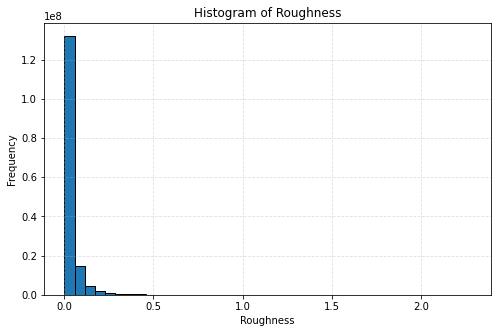

In [31]:
import matplotlib.pyplot as plt

# Extract roughness column from your collected list of Rows
roughness_values = [row['roughness'] for row in df_VV_roughness_col]

plt.figure(figsize=(8,5))
plt.hist(roughness_values, bins=40, edgecolor='black')
plt.xlabel("Roughness")
plt.ylabel("Frequency")
plt.title("Histogram of Roughness")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

#### plot the histogram in Spark-native way without collect

In [32]:
# Convert to RDD of floats
rdd_values = df_VV_roughness.select("roughness").rdd.flatMap(lambda x: x)

# Compute histogram with 40 bins
hist_bins, hist_counts = rdd_values.histogram(40)

print("Bin edges:", hist_bins)
print("Counts:", hist_counts)

Bin edges: [0.0017159384189860602, 0.05855091407118194, 0.11538588972337781, 0.1722208653755737, 0.22905584102776957, 0.2858908166799654, 0.3427257923321613, 0.3995607679843572, 0.45639574363655305, 0.513230719288749, 0.5700656949409448, 0.6269006705931407, 0.6837356462453367, 0.7405706218975325, 0.7974055975497284, 0.8542405732019243, 0.9110755488541201, 0.967910524506316, 1.0247455001585117, 1.0815804758107077, 1.1384154514629035, 1.1952504271150994, 1.2520854027672952, 1.3089203784194912, 1.3657553540716871, 1.4225903297238829, 1.4794253053760789, 1.5362602810282746, 1.5930952566804706, 1.6499302323326663, 1.7067652079848623, 1.763600183637058, 1.820435159289254, 1.87727013494145, 1.9341051105936458, 1.9909400862458417, 2.0477750618980375, 2.1046100375502332, 2.1614450132024294, 2.218279988854625, 2.275114964506821]
Counts: [132111369, 14880844, 4411791, 1909214, 978294, 537411, 303236, 174499, 102044, 60612, 36738, 22476, 14182, 8865, 5546, 3626, 2272, 1527, 965, 654, 443, 313, 214

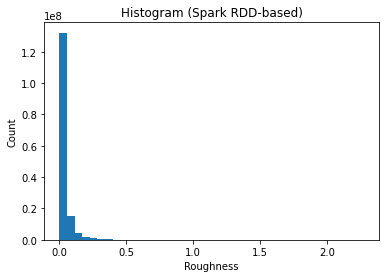

In [33]:
plt.bar(hist_bins[:-1], hist_counts, width=np.diff(hist_bins), align='edge')
plt.xlabel("Roughness")
plt.ylabel("Count")
plt.title("Histogram (Spark RDD-based)")
plt.show()